# 5 — Plotting

**Theme:** the built-in plots and the arguments that control them.

Four plotting methods cover most needs. Every one returns the Matplotlib
figure and axes, so anything not offered as an argument can still be done
afterwards with ordinary Matplotlib.

Specialised plots live with their topics:
[8 — PSD fitting](08-psd-fitting.ipynb),
[10a — Correlation and agreement](10a-correlation-and-agreement.ipynb) and
[13 — APS](13-aps.ipynb).

In [1]:
import matplotlib.pyplot as plt

import aerosoltools as at

elpi = at.load_elpi_file("../../tests/data/Sample_ELPI.txt")
elpi.mark_activities({
    "Background": [("2023-09-07 09:06:50", "2023-09-07 09:07:50")],
    "Emission":   [("2023-09-07 09:07:55", "2023-09-07 09:08:30")],
    "Decay":      [("2023-09-07 09:09:00", "2023-09-07 09:10:50")],
})

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/runner/work/aerosoltools/aerosoltools/src/aerosoltools/loaders/elpi.py:525: RuntimeWarning: ELPI density is not 1.0 g/cm3; bin edges were estimated from geometric means of CalculatedDi values.
  return load_elpi_file_txt(


## Total concentration over time

`plot_total_conc` is the simplest view: one line, whatever the instrument's
primary measurement is. It works on every class.

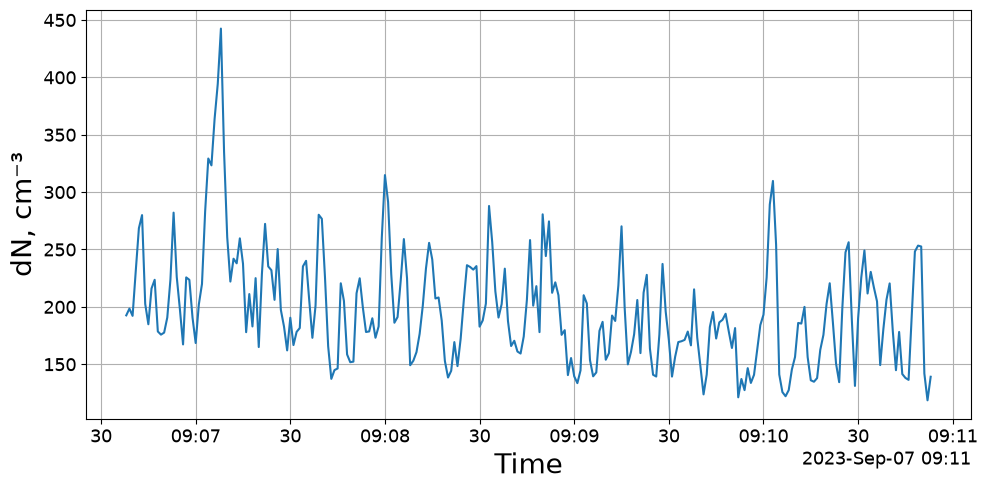

In [2]:
fig, ax = elpi.plot_total_conc()

`mark_activities=True` shades the marked periods, which is usually what makes a
time series readable.

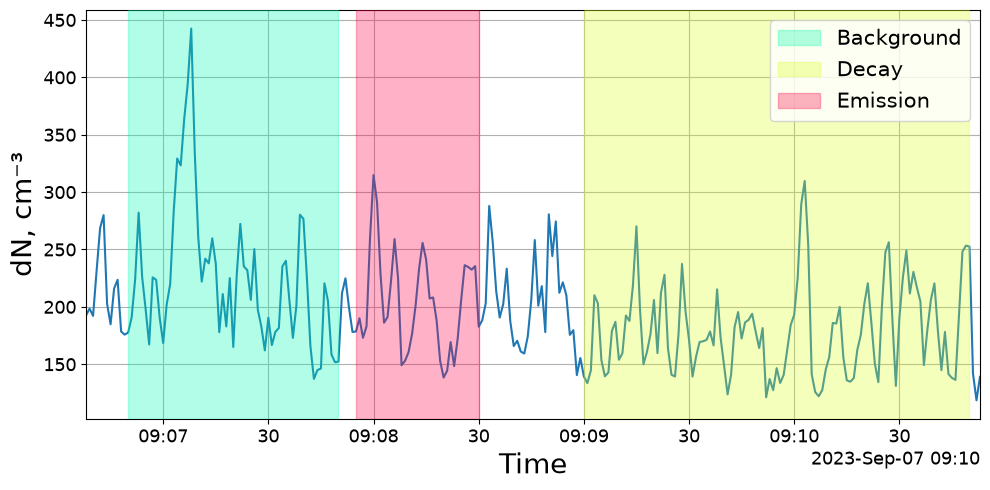

In [3]:
fig, ax = elpi.plot_total_conc(mark_activities=True)

Pass a list instead of `True` to shade only some activities.

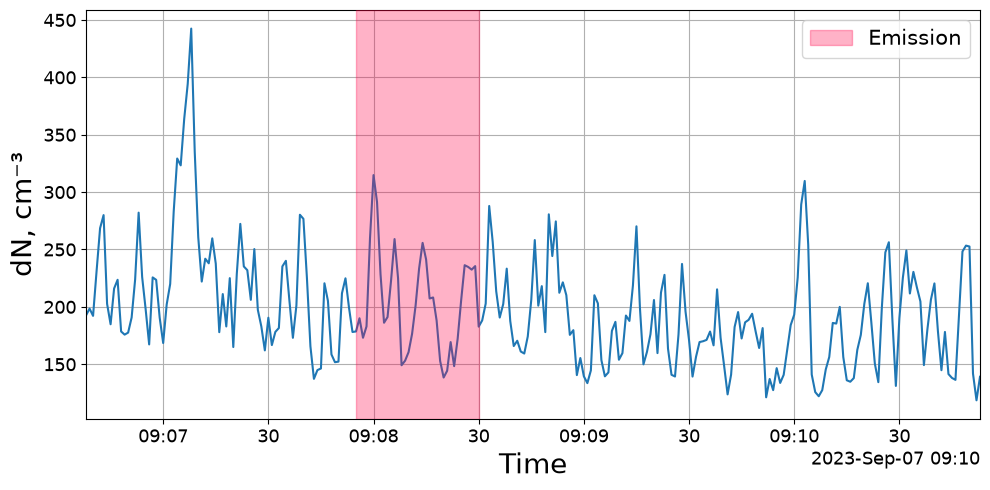

In [4]:
fig, ax = elpi.plot_total_conc(mark_activities=["Emission"])

## Size-resolved time series

For size-resolved data `plot_timeseries` adds a heat map of the size
distribution below the total concentration.


WARNING (plot_timeseries):
  PSD data contain zero or negative values, or the lower
  color-scale limit is ≤ 0. Falling back to *linear*
  color scale for the concentration heatmap.

  To enforce log-scaled concentration, set y_3d to use a
  strictly positive lower limit, for example:
      y_3d = (1, 0)
  which clips values below 1 and allows log scaling.



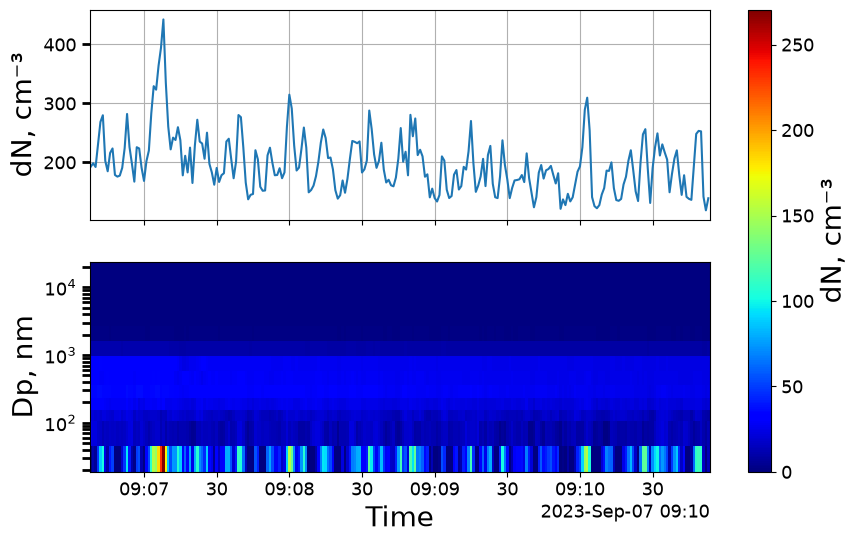

In [5]:
fig, axs = elpi.plot_timeseries()

Two arguments control the axes:

- `y_tot` — limits for the total-concentration panel
- `y_3d` — colour limits for the heat map

In both, `0` means "use the data". The lower bound on `y_3d` matters: the
colour scale is logarithmic by default, and bins reading exactly zero cannot be
shown on a log scale, so setting a floor of 1 avoids a mostly empty plot.

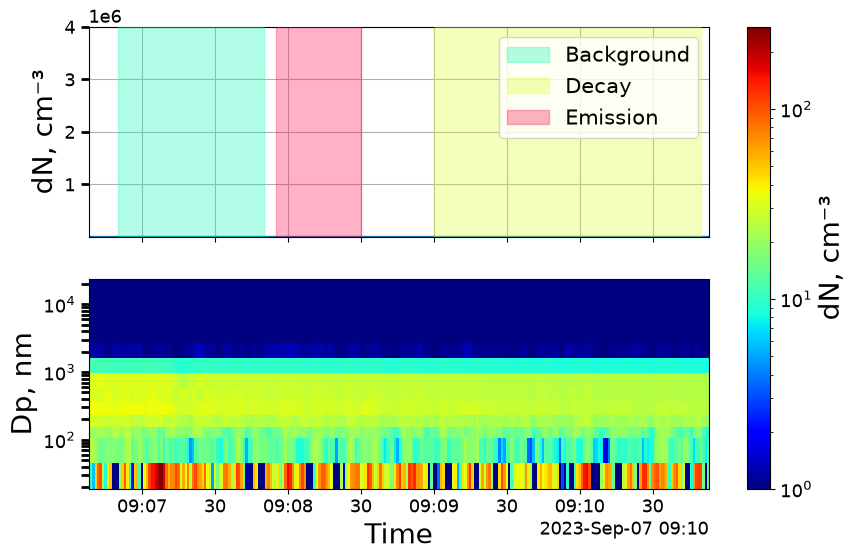

In [6]:
fig, axs = elpi.plot_timeseries(y_3d=(1, 0), y_tot=(0, 4e6), mark_activities=True)

`log=False` switches the heat map to a linear colour scale.

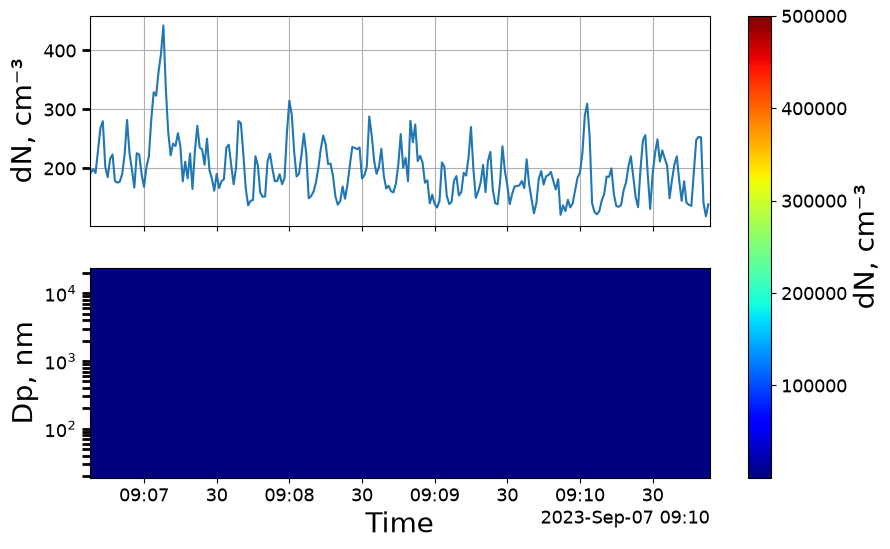

In [7]:
fig, axs = elpi.plot_timeseries(y_3d=(1, 5e5), log=False)

## Size distributions

`plot_psd` draws the average size distribution. With activities marked it draws
one curve per activity, which is the quickest way to see how a process changed
the distribution.

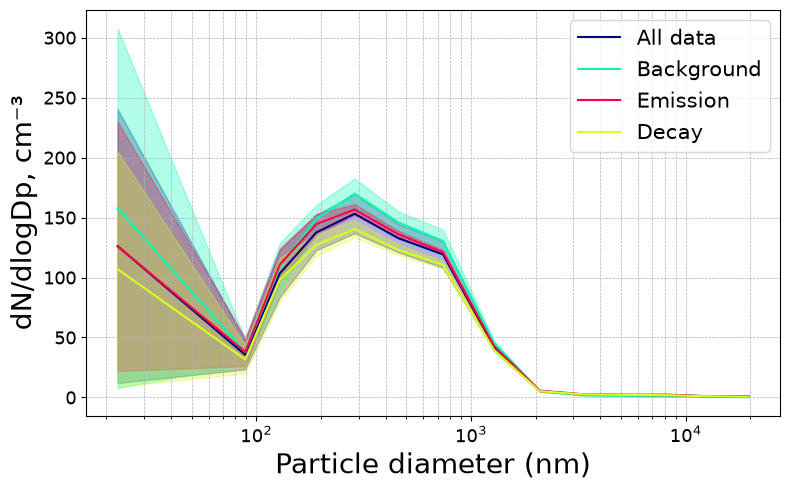

In [8]:
fig, ax = elpi.plot_psd()

`activities` selects which curves to draw.

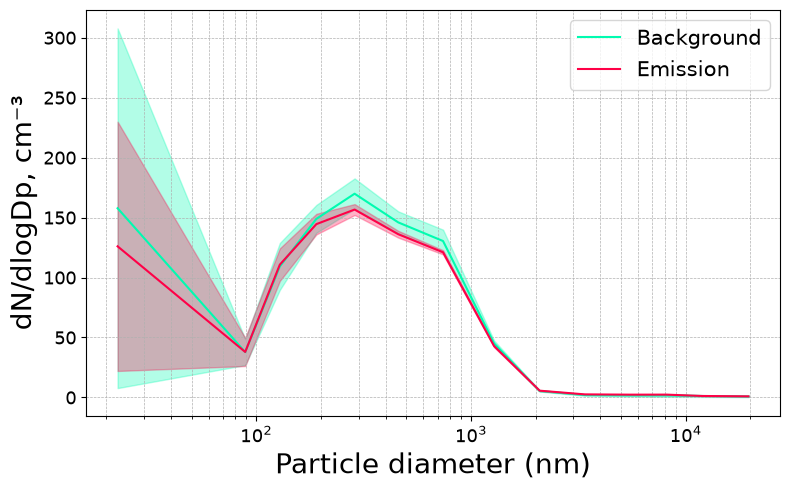

In [9]:
fig, ax = elpi.plot_psd(activities=["Background", "Emission"])

`normalize` controls dlogDp normalisation. Normalised distributions
(`dN/dlogDp`, the default) are comparable between instruments with different
bin widths; unnormalised ones show the raw per-bin concentration.

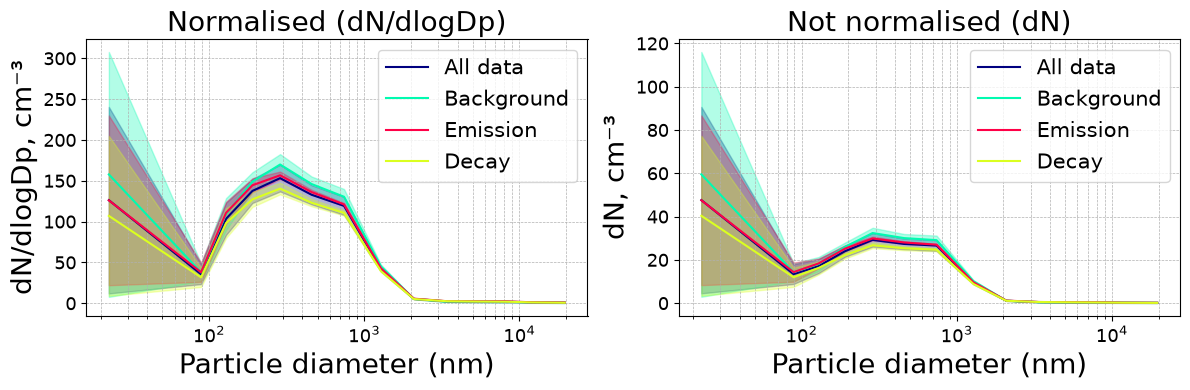

In [10]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))
elpi.plot_psd(normalize=True, ax=axs[0])
axs[0].set_title("Normalised (dN/dlogDp)")
elpi.plot_psd(normalize=False, ax=axs[1])
axs[1].set_title("Not normalised (dN)")
plt.tight_layout()

## PM fractions over time

`plot_PM_timeseries` draws cumulative mass fractions. `PM_values` chooses the
cut diameters, in µm.

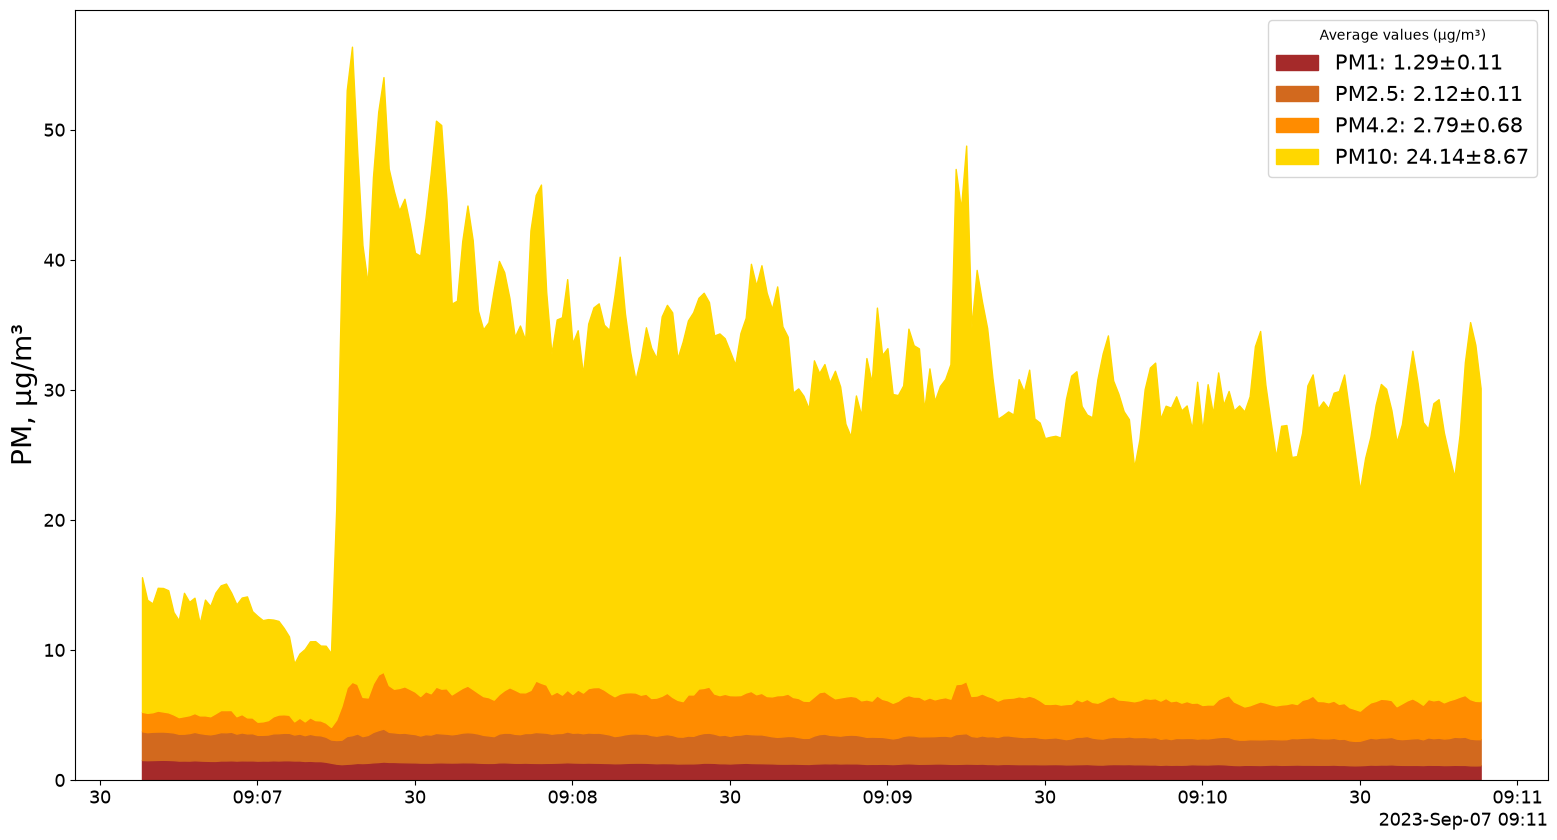

In [11]:
fig, ax = elpi.plot_PM_timeseries(PM_values=[1, 2.5, 4.2, 10])

`fraction=True` plots each cut as a share of the total rather than an absolute
concentration — useful for seeing a shift between coarse and fine particles
that an absolute plot hides.

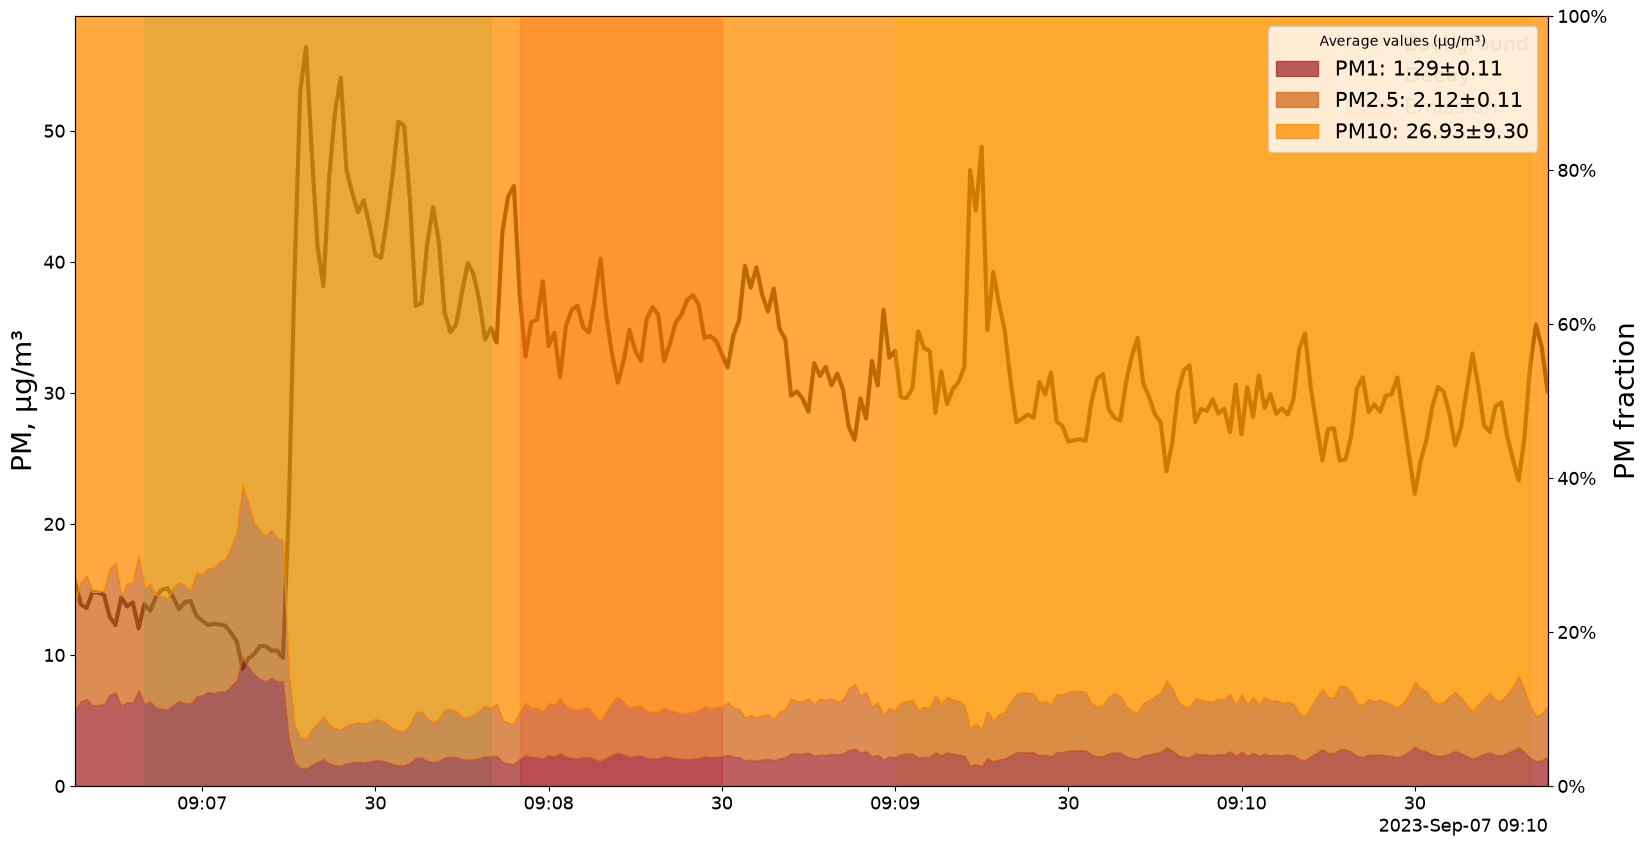

In [12]:
fig, ax = elpi.plot_PM_timeseries(PM_values=[1, 2.5, 10], fraction=True,
                                  mark_activities=True)

## Supplying your own axes

Every method takes an axes argument (`ax`, or `ax1`/`ax2` for the two-panel
time series), so plots can be composed into a figure you control.

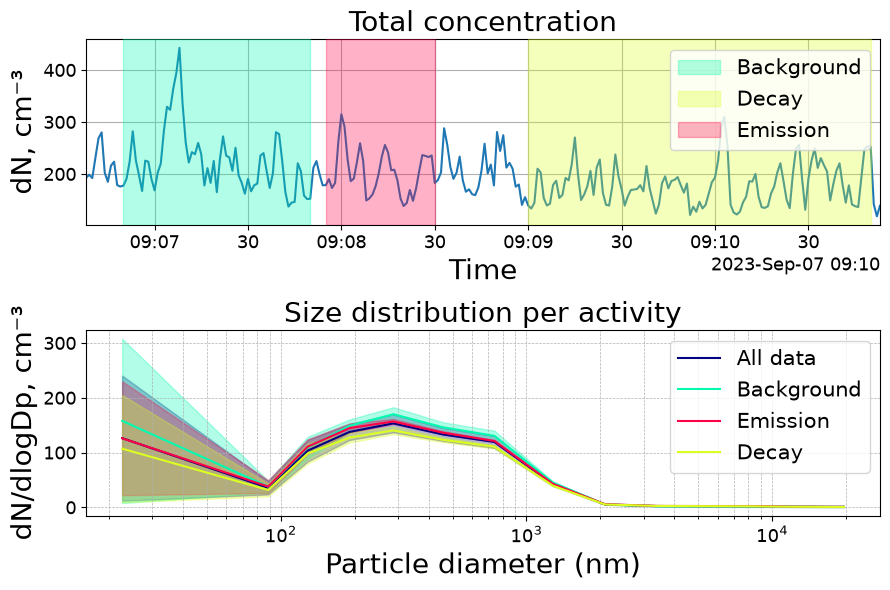

In [13]:
fig, axs = plt.subplots(nrows=2, figsize=(9, 6))

elpi.plot_total_conc(axs[0], mark_activities=True)
axs[0].set_title("Total concentration")

elpi.plot_psd(ax=axs[1])
axs[1].set_title("Size distribution per activity")

plt.tight_layout()

Because the figure and axes are returned, the result is an ordinary Matplotlib
figure — restyle, annotate or save it however you normally would.

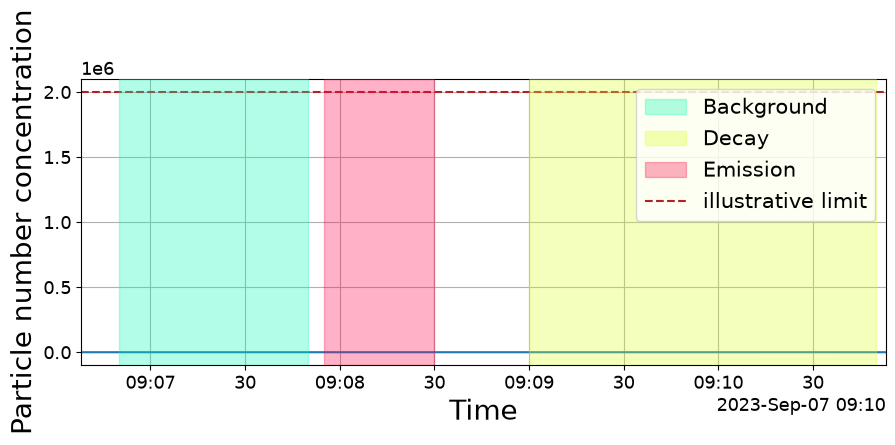

In [14]:
fig, ax = elpi.plot_total_conc(mark_activities=True)
ax.set_ylabel("Particle number concentration")
ax.axhline(2e6, linestyle="--", color="firebrick", label="illustrative limit")
ax.legend(loc="upper right")
fig.set_size_inches(9, 3.5)

---

**Next:** [6 — Dtypes, density and corrections](06-dtypes-density-corrections.ipynb).